In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import math

from pangya_physics.club import CLUBS
from pangya_physics.wind import Wind
from pangya_physics.solver import simulate_distance, create_initial_velocity

In [8]:
smartcalc = pd.DataFrame({
    "club": [
        "1W", "2W", "2I", "3W", "3I", "4I",
        "5I", "6I", "7I", "8I", "9I", "PW", "SW"
    ],
    "smartcalc_distance": [
        348.47, 338.38, 316.06, 314.59, 314.12, 306.11,
        296.52, 283.29, 268.36, 255.83, 239.39, 222.88, 172.97
    ]
})

smartcalc

,club,smartcalc_distance
0,1W,348.47
1,2W,338.38
2,2I,316.06
3,3W,314.59
4,3I,314.12
5,4I,306.11
6,5I,296.52
7,6I,283.29
8,7I,268.36
9,8I,255.83


In [9]:
wind = Wind(0, 0)

python_results = []

for club_name, club in CLUBS.items():
    velocity = create_initial_velocity(
        club=club,
        power_percent=1.0,
    )

    python_distance = simulate_distance(
        club=club,
        wind=wind,
        velocity_y=velocity.y,
        velocity_z=velocity.z,
    )

    python_results.append({
        "club": club_name,
        "python_distance": python_distance,
    })

python_df = pd.DataFrame(python_results)
python_df

,club,python_distance
0,1W,348.470713
1,2W,338.381296
2,3W,314.588992
3,2I,316.060393
4,3I,314.117281
5,4I,306.111441
6,5I,296.524395
7,6I,283.293298
8,7I,268.356404
9,8I,255.832702


Um comportamento interessante observado é que o 2I apresenta distância máxima levemente superior ao 3W. Como o mesmo padrão aparece tanto no baseline da Smart Calc quanto na implementação Python, isso indica que a diferença provavelmente vem dos próprios parâmetros físicos do modelo original, não de erro na reimplementação.

In [10]:
comparison = smartcalc.merge(
    python_df,
    on="club",
    how="inner",
)

comparison["delta"] = (
    comparison["python_distance"]
    - comparison["smartcalc_distance"]
)

comparison["abs_delta"] = comparison["delta"].abs()

comparison["pct_error"] = (
    comparison["delta"]
    / comparison["smartcalc_distance"]
) * 100

comparison

,club,smartcalc_distance,python_distance,delta,abs_delta,pct_error
0,1W,348.47,348.470713,0.000713,0.000713,0.000205
1,2W,338.38,338.381296,0.001296,0.001296,0.000383
2,2I,316.06,316.060393,0.000393,0.000393,0.000124
3,3W,314.59,314.588992,-0.001008,0.001008,-0.000321
4,3I,314.12,314.117281,-0.002719,0.002719,-0.000866
5,4I,306.11,306.111441,0.001441,0.001441,0.000471
6,5I,296.52,296.524395,0.004395,0.004395,0.001482
7,6I,283.29,283.293298,0.003298,0.003298,0.001164
8,7I,268.36,268.356404,-0.003596,0.003596,-0.001340
9,8I,255.83,255.832702,0.002702,0.002702,0.001056


In [11]:
summary = {
    "mean_error": comparison["delta"].mean(),
    "mean_abs_error": comparison["abs_delta"].mean(),
    "max_abs_error": comparison["abs_delta"].max(),
    "rmse": math.sqrt((comparison["delta"] ** 2).mean()),
    "mean_pct_error": comparison["pct_error"].mean(),
}

summary

{'mean_error': np.float64(0.0011917168041249554),
 'mean_abs_error': np.float64(0.00231838897825189),
 'max_abs_error': np.float64(0.004633824638887063),
 'rmse': 0.00267072712392276,
 'mean_pct_error': np.float64(0.00049656017553504)}

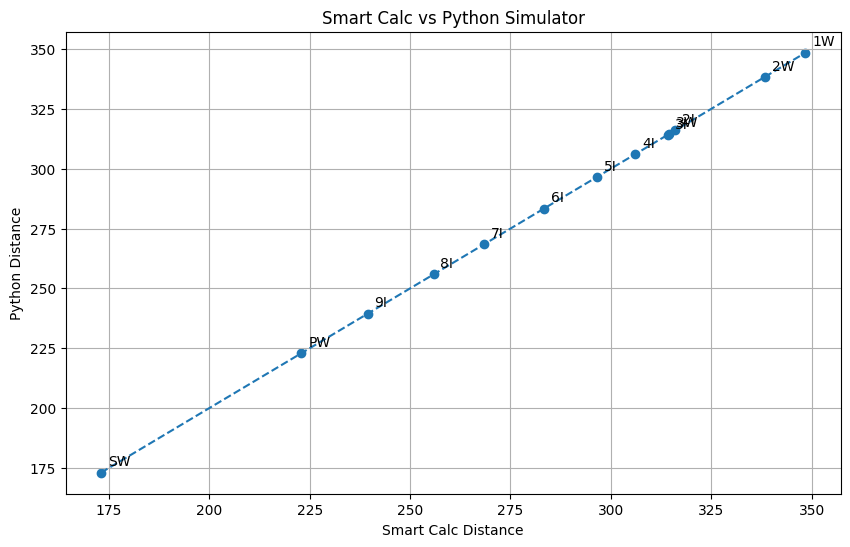

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    comparison["smartcalc_distance"],
    comparison["python_distance"],
)

min_value = min(
    comparison["smartcalc_distance"].min(),
    comparison["python_distance"].min(),
)

max_value = max(
    comparison["smartcalc_distance"].max(),
    comparison["python_distance"].max(),
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
)

for _, row in comparison.iterrows():
    plt.annotate(
        row["club"],
        (row["smartcalc_distance"], row["python_distance"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.title("Smart Calc vs Python Simulator")
plt.xlabel("Smart Calc Distance")
plt.ylabel("Python Distance")
plt.grid(True)

plt.show()

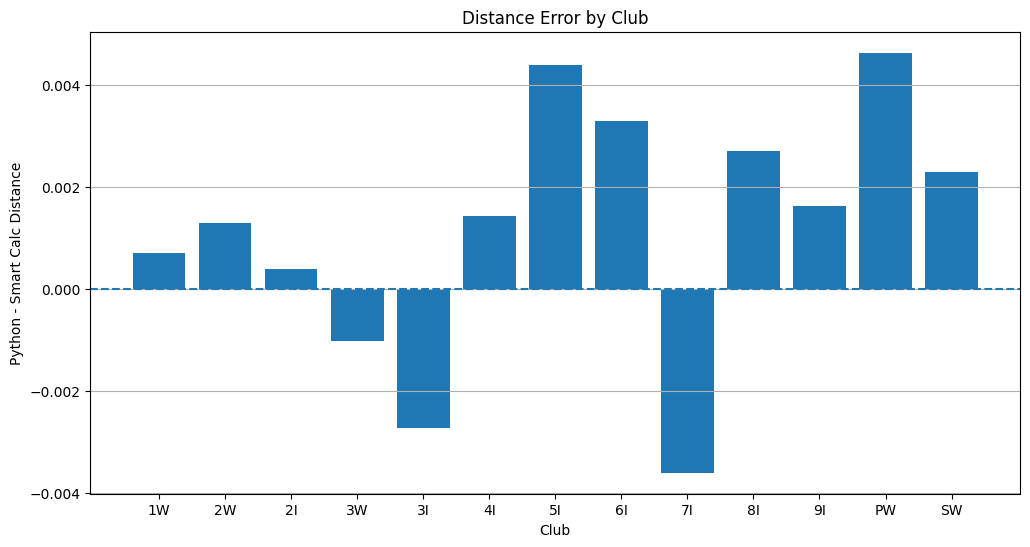

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison["club"],
    comparison["delta"],
)

plt.axhline(0, linestyle="--")

plt.title("Distance Error by Club")
plt.xlabel("Club")
plt.ylabel("Python - Smart Calc Distance")
plt.grid(axis="y")

plt.show()

In [14]:
comparison.sort_values("abs_delta", ascending=False)

,club,smartcalc_distance,python_distance,delta,abs_delta,pct_error
11,PW,222.88,222.884634,0.004634,0.004634,0.002079
6,5I,296.52,296.524395,0.004395,0.004395,0.001482
8,7I,268.36,268.356404,-0.003596,0.003596,-0.001340
7,6I,283.29,283.293298,0.003298,0.003298,0.001164
4,3I,314.12,314.117281,-0.002719,0.002719,-0.000866
9,8I,255.83,255.832702,0.002702,0.002702,0.001056
12,SW,172.97,172.972305,0.002305,0.002305,0.001333
10,9I,239.39,239.391638,0.001638,0.001638,0.000684
5,4I,306.11,306.111441,0.001441,0.001441,0.000471
1,2W,338.38,338.381296,0.001296,0.001296,0.000383


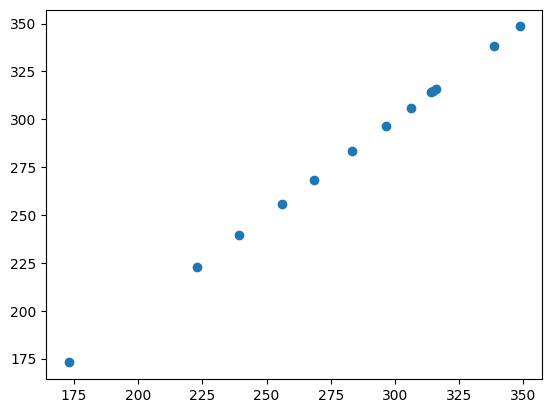

In [19]:
plt.scatter(
    comparison["smartcalc_distance"],
    comparison["python_distance"]
)

plt.savefig(
    PROJECT_ROOT / "docs" / "images" / "smartcalc_validation.png",
    dpi=300,
    bbox_inches="tight",
)